In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import seaborn as sns

# Load data

In [5]:
train_data = pd.read_csv('../data/raw/train.csv', index_col='id')
original_data = pd.read_csv('../data/raw/loan_dataset_20000.csv', usecols= train_data.columns.tolist())

# Initial data exploration

In [6]:
train_data.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000,593994.000000
mean,48212.202976,0.120696,680.916009,15020.297629,12.356345,0.798820
std,26711.942078,0.068573,55.424956,6926.530568,2.008959,0.400883
min,6002.430000,0.011000,395.000000,500.090000,3.200000,0.000000
25%,27934.400000,0.072000,646.000000,10279.620000,10.990000,1.000000
50%,46557.680000,0.096000,682.000000,15000.220000,12.370000,1.000000
75%,60981.320000,0.156000,719.000000,18858.580000,13.680000,1.000000
max,393381.740000,0.627000,849.000000,48959.950000,20.990000,1.000000


In [7]:
original_data.describe()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_paid_back
count,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000
mean,43549.637766,0.177019,679.25695,15129.300909,12.400626,0.799900
std,28668.579671,0.105059,69.63858,8605.405513,2.442729,0.400085
min,6000.000000,0.010000,373.00000,500.000000,3.140000,0.000000
25%,24260.752500,0.096000,632.00000,8852.695000,10.740000,1.000000
50%,36585.260000,0.160000,680.00000,14946.170000,12.400000,1.000000
75%,54677.917500,0.241000,727.00000,20998.867500,14.002500,1.000000
max,400000.000000,0.667000,850.00000,49039.690000,22.510000,1.000000


In [13]:
train_data.head()

,annual_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,gender,marital_status,education_level,employment_status,loan_purpose,grade_subgrade,loan_paid_back
id,,,,,,,,,,,,
0,29367.99,0.084,736,2528.42,13.67,Female,Single,High School,Self-employed,Other,C3,1.0
1,22108.02,0.166,636,4593.10,12.92,Male,Married,Master's,Employed,Debt consolidation,D3,0.0
2,49566.20,0.097,694,17005.15,9.76,Male,Single,High School,Employed,Debt consolidation,C5,1.0
3,46858.25,0.065,533,4682.48,16.10,Female,Single,High School,Employed,Debt consolidation,F1,1.0
4,25496.70,0.053,665,12184.43,10.21,Male,Married,High School,Employed,Other,D1,1.0


In [32]:
categorical_features = ['marital_status', 'education_level', 'gender', 'employment_status', 'loan_purpose', 'grade_subgrade']
numerical_features = ['annual_income', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'interest_rate']
target = 'loan_paid_back'
print(len(categorical_features) + len(numerical_features) + 1 == len(train_data.columns))

True


# Class distributions for categorical features

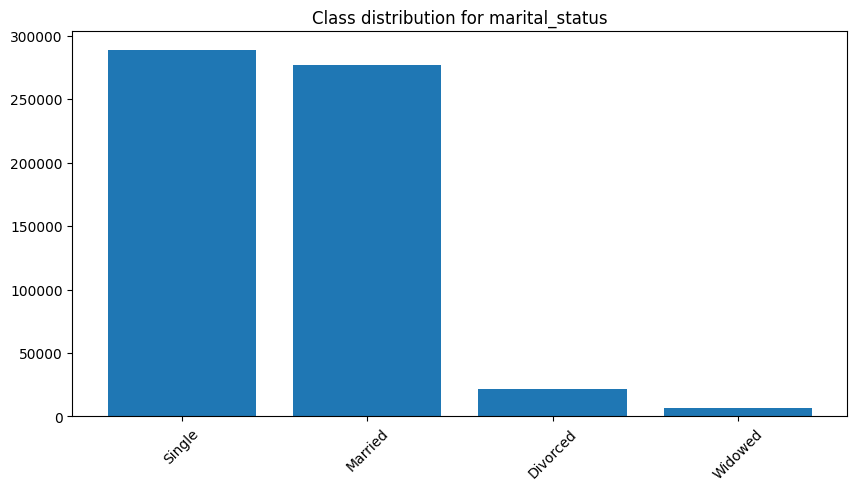

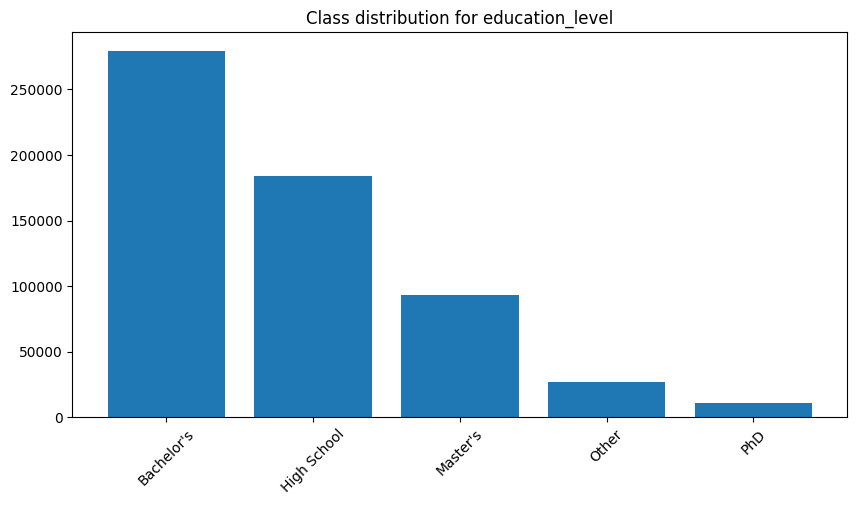

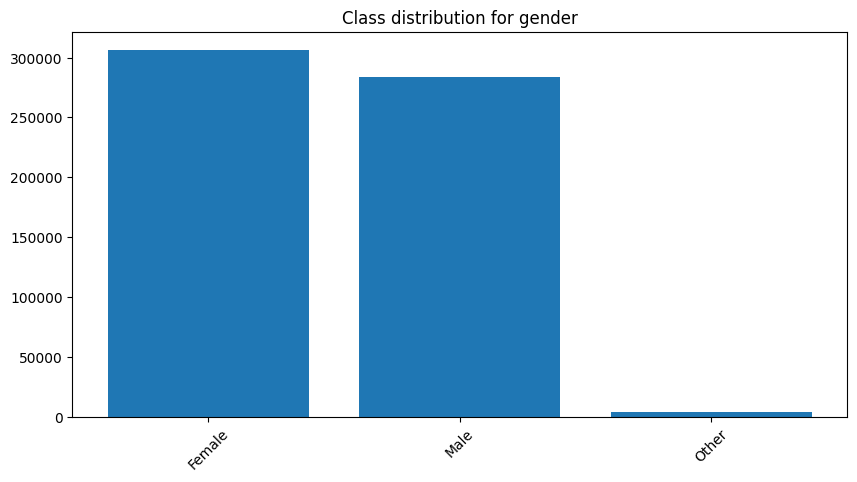

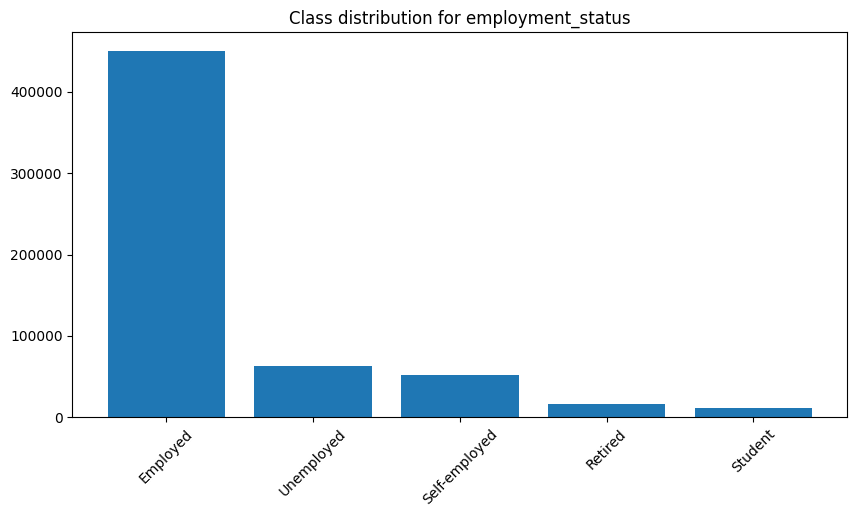

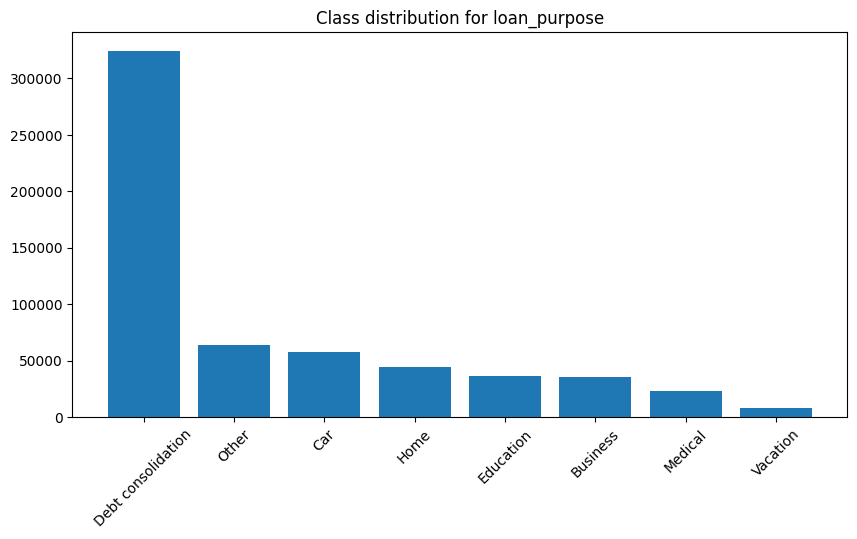

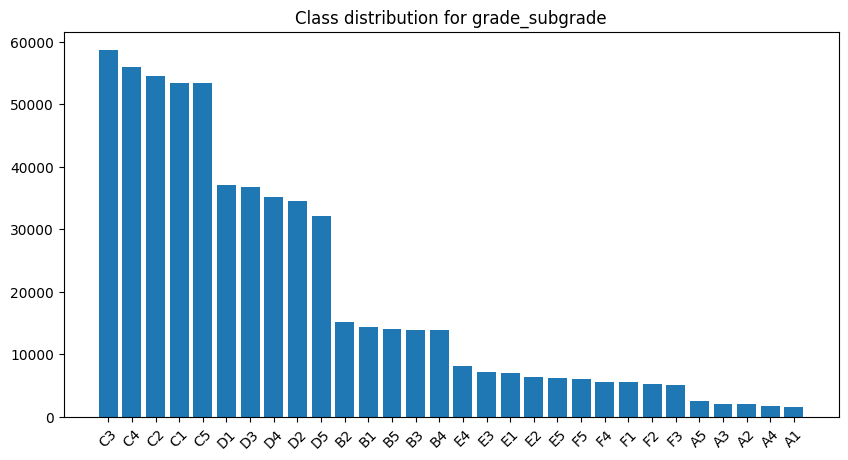

In [49]:
for feature in categorical_features:
    counts = train_data[feature].value_counts()

    plt.figure(figsize = (10, 5))
    plt.title(f'Class distribution for {feature}')
    plt.bar(x=counts.index, height=counts.values)
    plt.xticks(rotation=45)
    plt.show()

# Distributions for numerical features

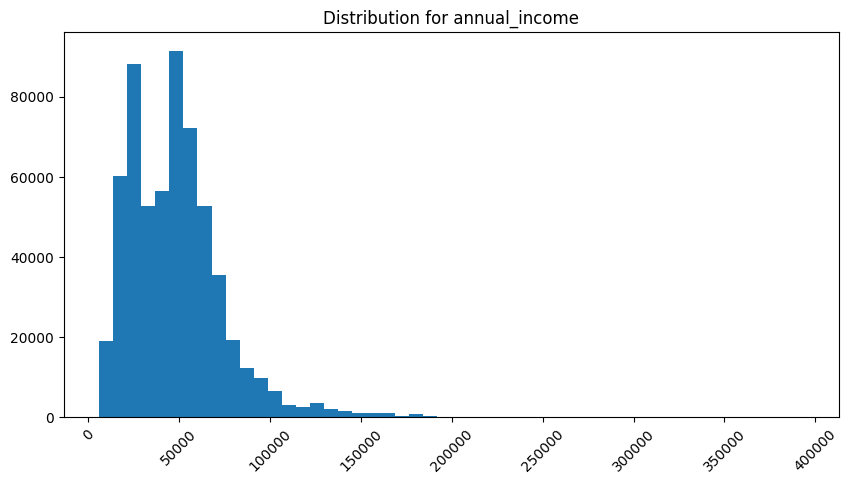

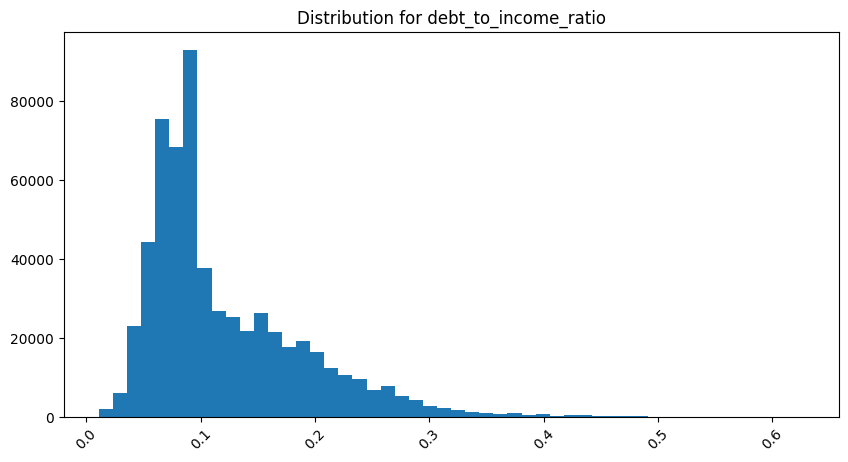

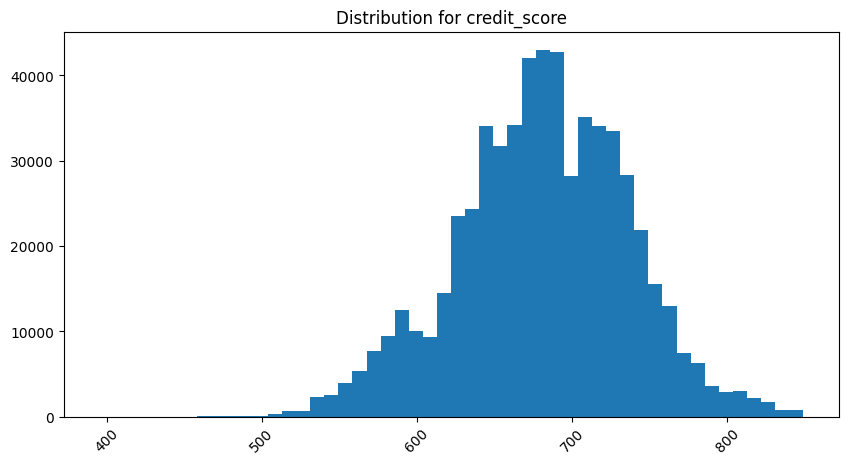

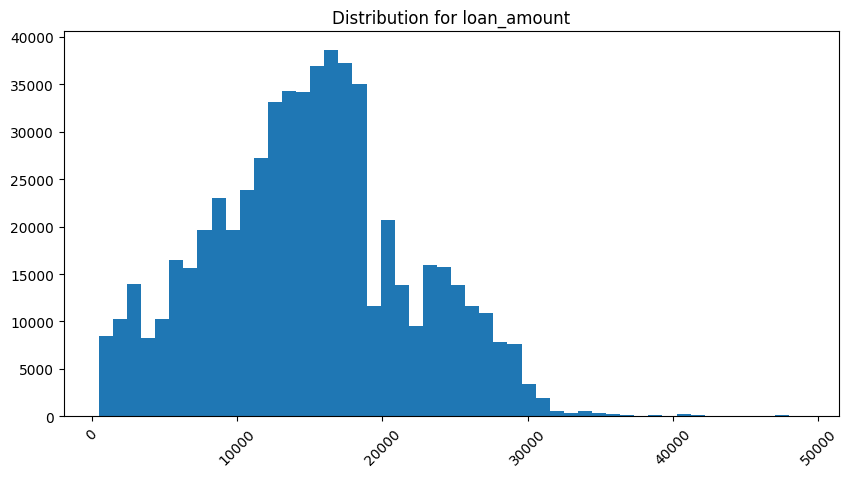

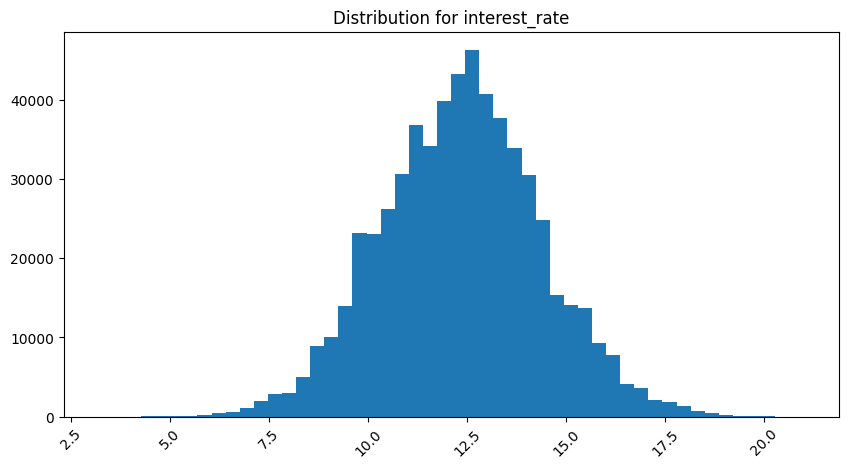

In [50]:
for feature in numerical_features:

    plt.figure(figsize = (10, 5))
    plt.title(f'Distribution for {feature}')
    plt.hist(train_data[feature], bins = 50)
    plt.xticks(rotation=45)
    plt.show()

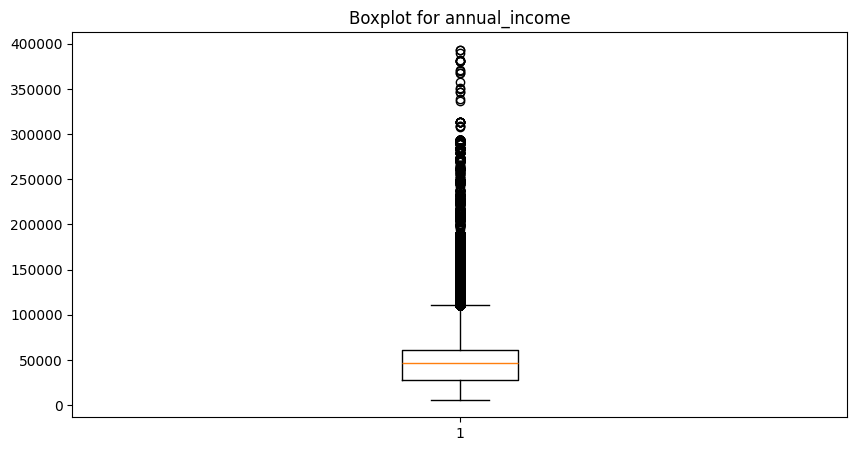

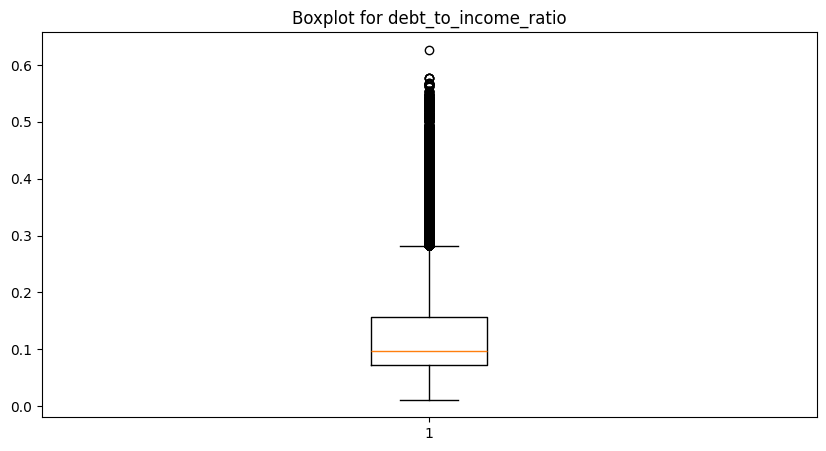

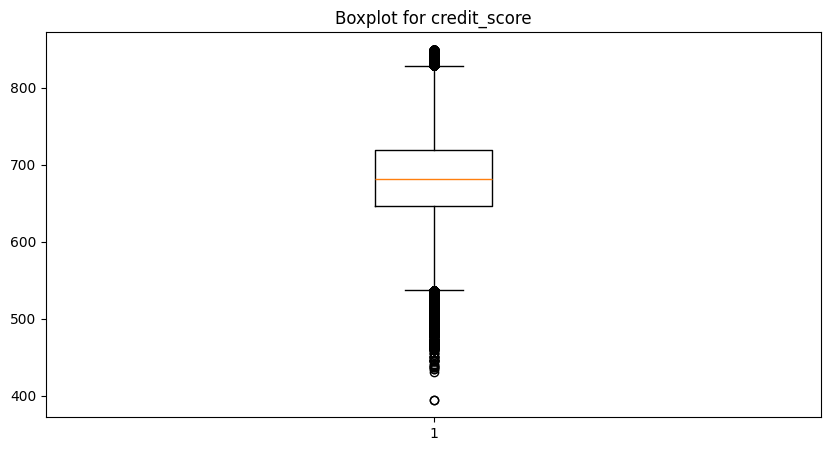

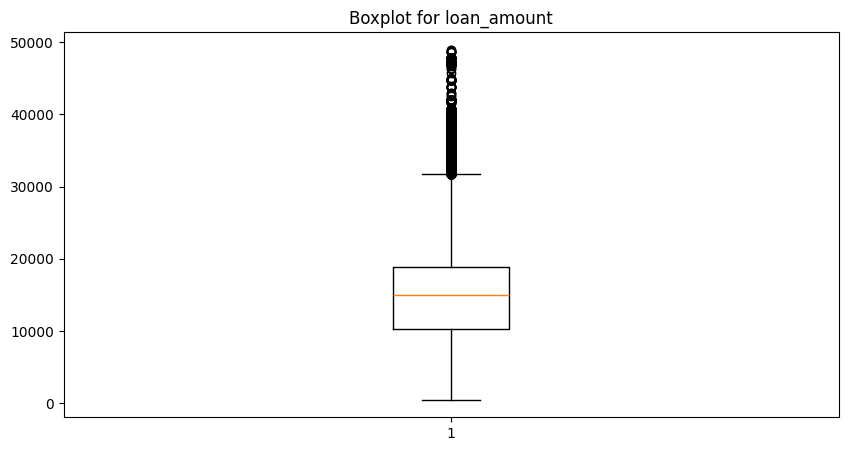

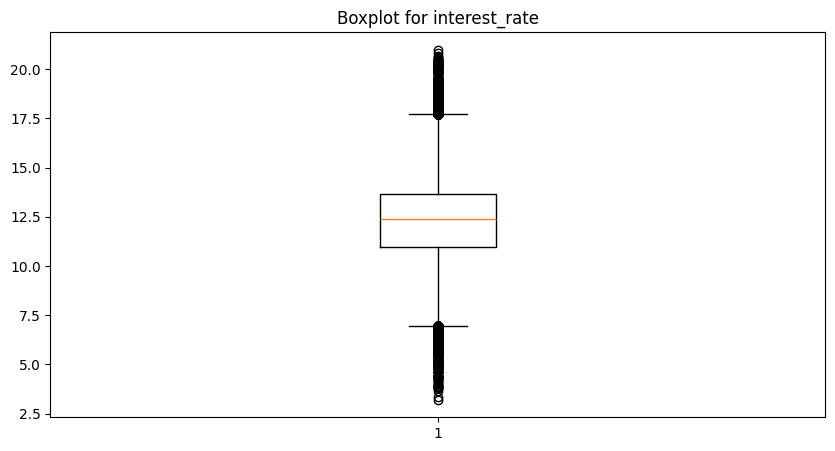

In [51]:
for feature in numerical_features:

    plt.figure(figsize = (10, 5))
    plt.title(f'Boxplot for {feature}')
    plt.boxplot(train_data[feature])
    plt.show()

# Bivariate analysis

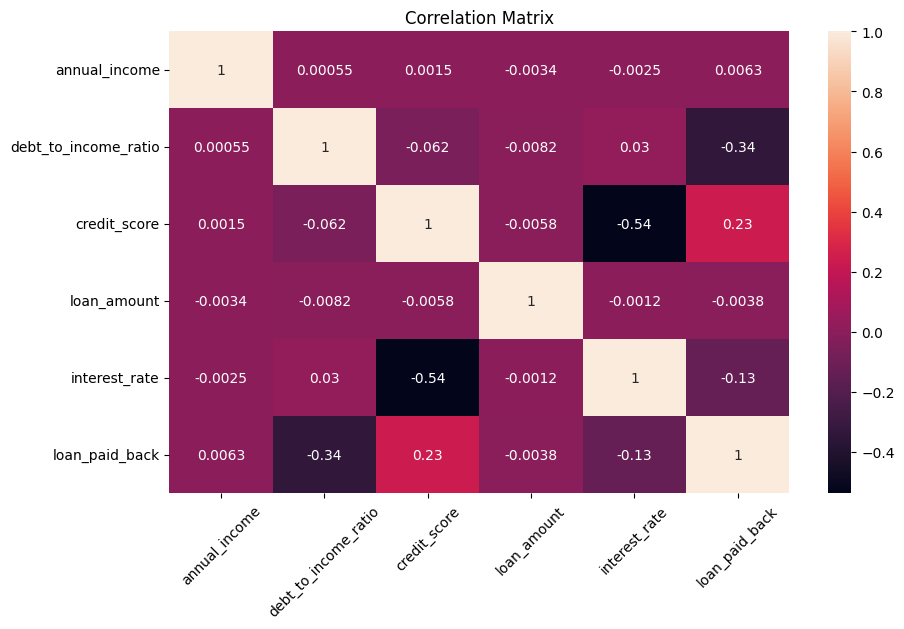

In [57]:
plt.figure(figsize = (10, 6))
corr_matrix = train_data[numerical_features + [target]].corr()
sns.heatmap(corr_matrix, annot=True)

plt.title('Correlation Matrix')
plt.xticks(rotation=45)
plt.show()

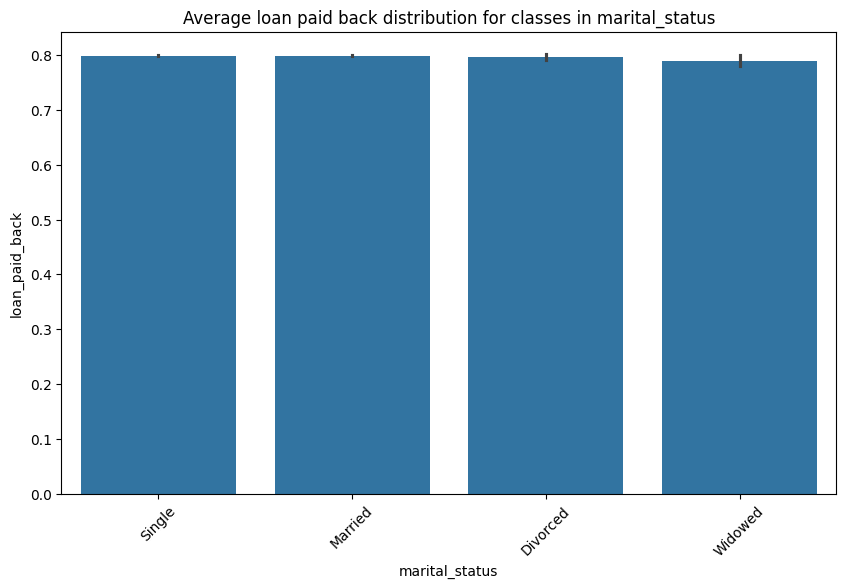

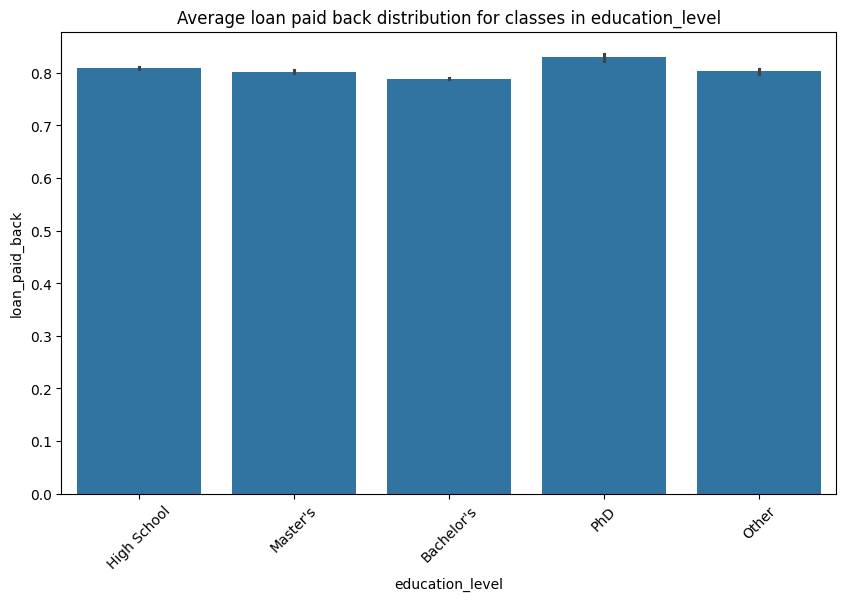

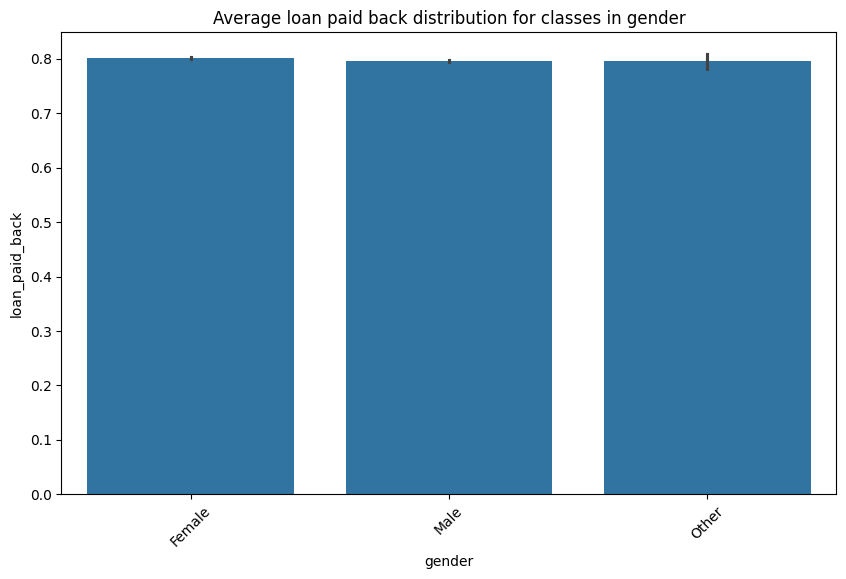

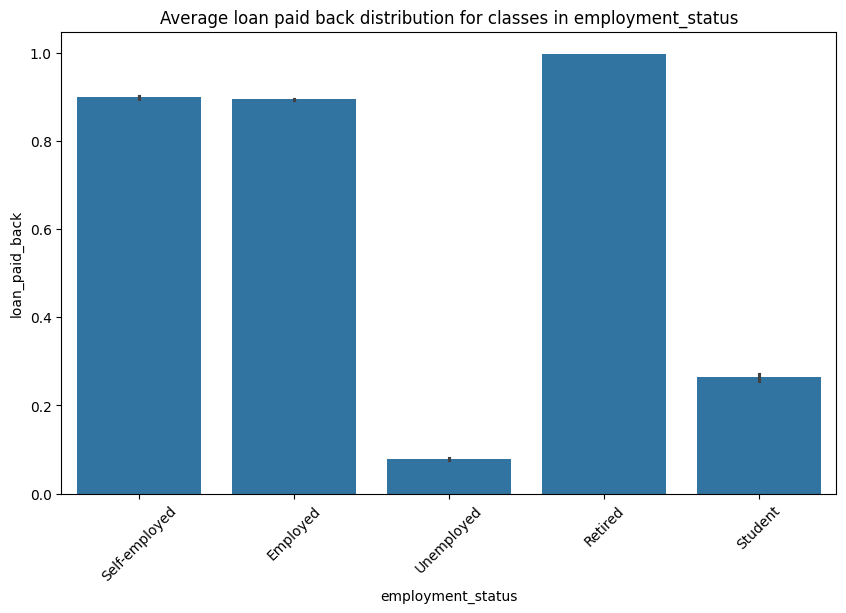

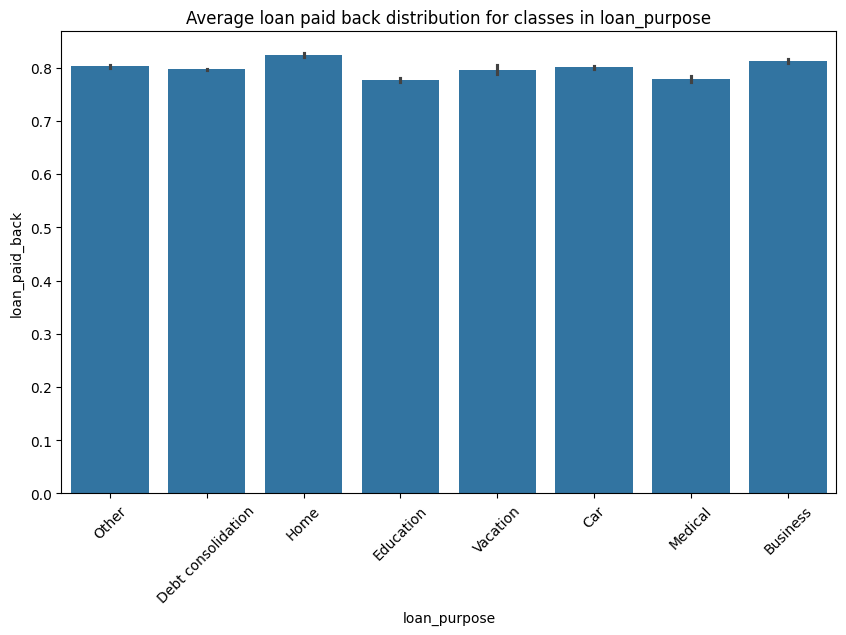

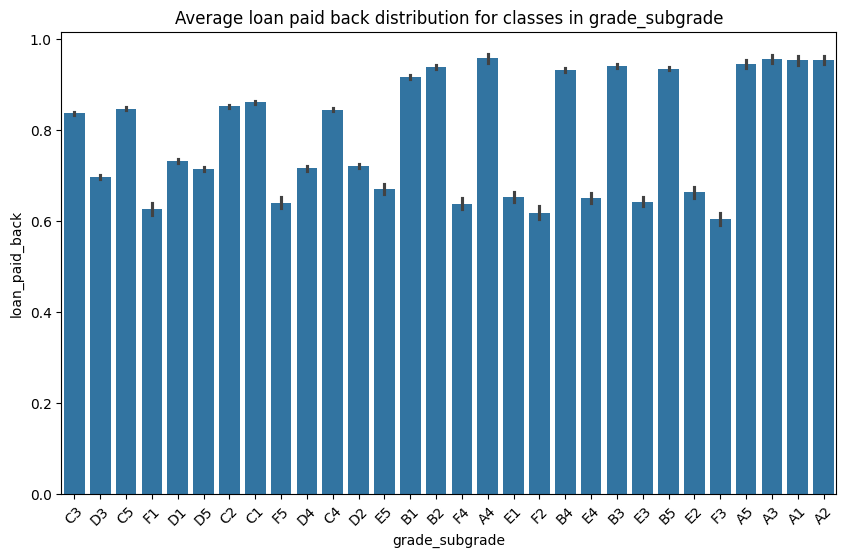

In [55]:
for feature in categorical_features:
    plt.figure(figsize = (10, 6))
    sns.barplot(data=train_data[categorical_features + [target]], x=feature, y=target)

    plt.title(f'Average loan paid back distribution for classes in {feature}')
    plt.xticks(rotation=45)
    plt.show()


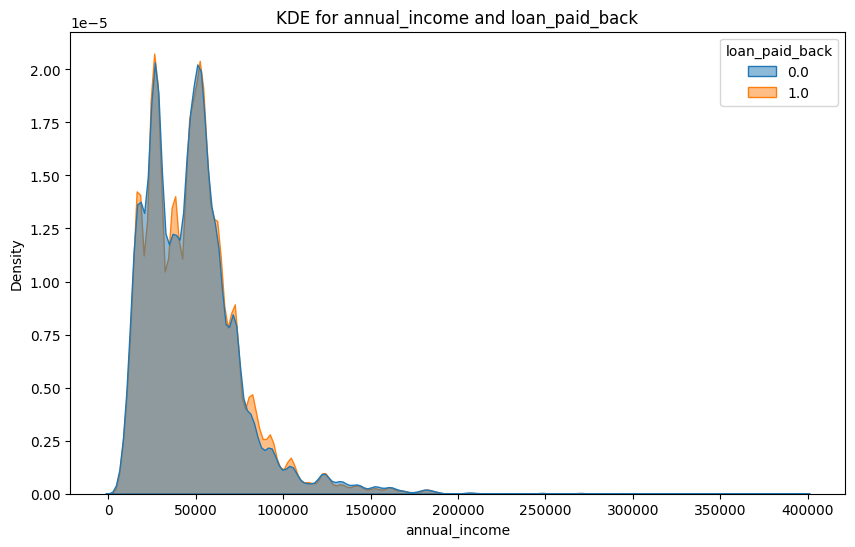

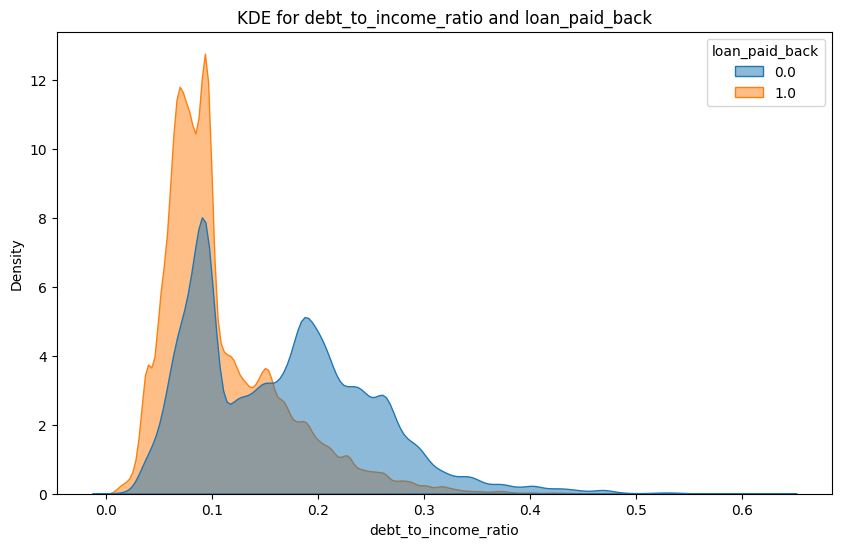

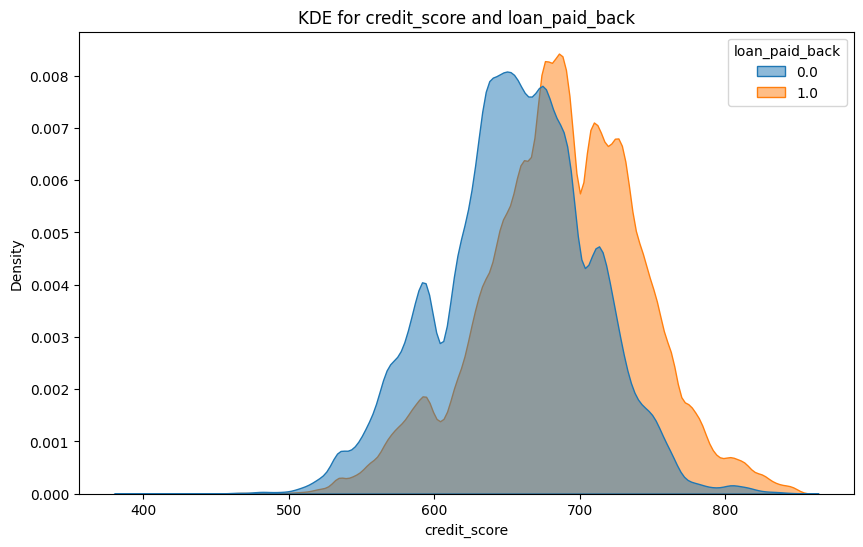

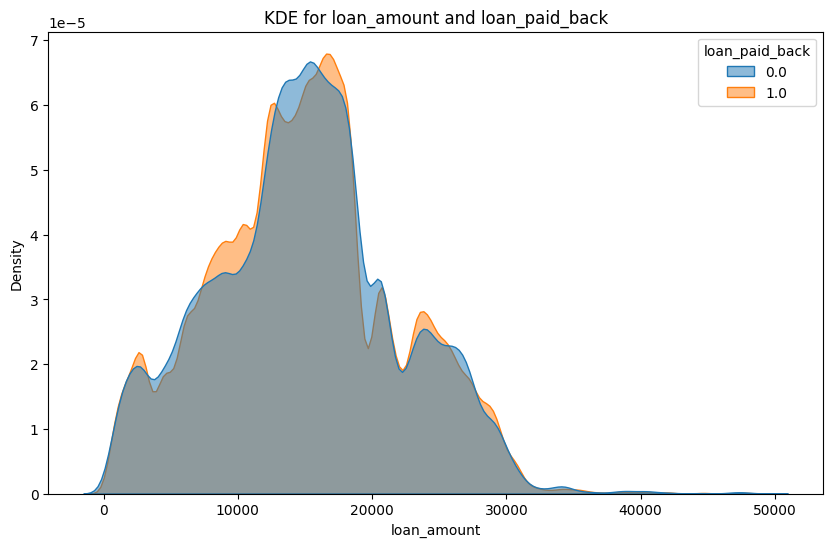

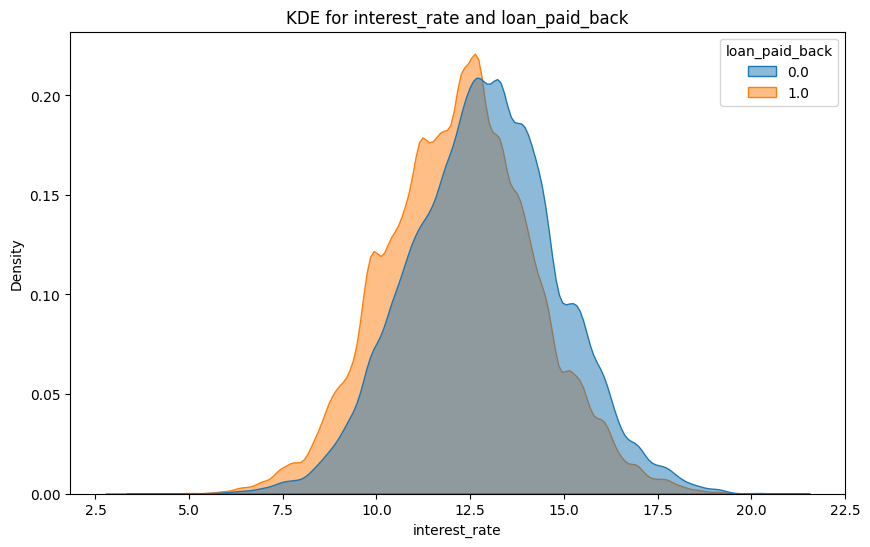

In [68]:
for feature in numerical_features:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(
        data=train_data,
        x=feature,
        hue=target,
        fill=True,
        common_norm=False,
        alpha=0.5
    )
    plt.title(f'KDE for {feature} and {target}')
    plt.show()

# Target class balance analysis

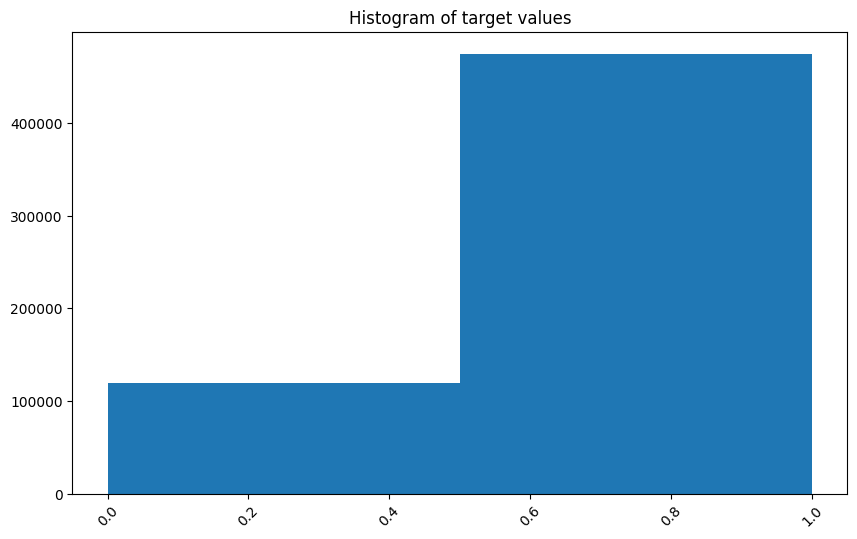

Percent of loans paid back is 79.88%


In [70]:
plt.figure(figsize = (10, 6))
plt.hist(train_data[target], bins = 2)
plt.title('Histogram of target values')
plt.xticks(rotation=45)
plt.show()
target_paid_percentage = train_data[target].sum() / train_data[target].count()
print(f'Percent of loans paid back is {target_paid_percentage * 100:.2f}%')